<a href="https://colab.research.google.com/github/Mohommad-Nuzlan-GH/M-R-M-Nuzlan-Database-Analytics-Top-Up-2026/blob/main/4_Python_Analysis_NS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#1 Import libraries for data analysis
import pandas as pd
import numpy as np

#2 Import libraries for visualisation
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#3 Load cleaned datasets
CUSTOMER = pd.read_csv('1#clean_customers.csv')
APP_EVENT = pd.read_csv('2#clean_app_events.csv')
ORDER = pd.read_csv('3#clean_orders.csv')
COMPLAINT = pd.read_csv('4#clean_complaints.csv')
DELIVERY = pd.read_csv('5#clean_deliveries.csv')
DRIVER = pd.read_csv('6#clean_drivers.csv')
VEHICLE = pd.read_csv('7#clean_vehicles.csv')
HUB = pd.read_csv('8#clean_hubs.csv')
INCIDENT = pd.read_csv('9#clean_incidents.csv')

In [3]:
#4 Initial dataset checks
print("CUSTOMER:", CUSTOMER.shape)
print("ORDER:", ORDER.shape)
print("DELIVERY:", DELIVERY.shape)
print("COMPLAINT:", COMPLAINT.shape)
print("APP_EVENT:", APP_EVENT.shape)

CUSTOMER: (650, 10)
ORDER: (1250, 12)
DELIVERY: (950, 16)
COMPLAINT: (320, 11)
APP_EVENT: (640, 12)


In [4]:
#-------------------(1)_CREATE MASTER ANALYTICAL DATASET---------------------
#1 Merge datasets step-by-step
analysis_df = DELIVERY.merge(ORDER, on='order_id', how='left')
analysis_df = analysis_df.merge(CUSTOMER, on='customer_id', how='left')
analysis_df = analysis_df.merge(DRIVER, on='driver_id', how='left')
analysis_df = analysis_df.merge(VEHICLE, on='vehicle_id', how='left')
analysis_df = analysis_df.merge(HUB, on='hub_id', how='left')

#2 Check dataset
print("Combined dataset shape:", analysis_df.shape)
display(analysis_df.head())

Combined dataset shape: (950, 57)


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,battery_health_pct,odometer_km,maintenance_status,telematics_version,battery_health_category,hub_name,zone,hub_type,capacity_score,capacity_category
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2026-04-28 05:59:54,Failed,17.26,1,...,78.4,29849,Active,v2.2,Medium,Central Core,Central,Control,88,High
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,NaN,Ontime,10.34,1,...,68.6,78468,Active,v2.2,Medium,South Link,South,Dispatch,78,High
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,NaN,Ontime,7.92,0,...,55.9,15278,Active,v2.2,Low,South Link,South,Dispatch,78,High
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,NaN,Delayed,16.42,0,...,83.3,85635,Active,v2.1,High,South Link,South,Dispatch,78,High
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,NaN,Ontime,14.52,1,...,94.2,210683,Inrepair,v2.0,High,North Exchange,North,Dispatch,82,High


In [5]:
#-------------------(2)_CREATE KPI FLAGS---------------------
#1 Delivery issue flags
analysis_df['is_failed'] = (analysis_df['delivery_status'] == 'Failed').astype(int)
analysis_df['is_delayed'] = (analysis_df['delivery_status'] == 'Delayed').astype(int)

#2 Combined problem flag
analysis_df['is_problem'] = ((analysis_df['is_failed'] + analysis_df['is_delayed']) > 0).astype(int)

#3 Preview
analysis_df[['delivery_status','is_failed','is_delayed','is_problem']].head()

,delivery_status,is_failed,is_delayed,is_problem
0,Failed,1,0,1
1,Ontime,0,0,0
2,Ontime,0,0,0
3,Delayed,0,1,1
4,Ontime,0,0,0


In [6]:
#-------------------(3)_HUB KPI ANALYSIS---------------------
#1 Aggregate hub performance
hub_kpi = analysis_df.groupby('hub_name').agg(
    total_deliveries=('delivery_id', 'count'),
    failed=('is_failed', 'sum'),
    delayed=('is_delayed', 'sum'),
    problems=('is_problem', 'sum'),
    avg_rating=('customer_rating_post_delivery', 'mean')
).reset_index()

#2 KPI calculation
hub_kpi['problem_rate'] = round(100 * hub_kpi['problems'] / hub_kpi['total_deliveries'], 2)

#3 Filter meaningful hubs
hub_kpi = hub_kpi[hub_kpi['total_deliveries'] >= 20]

#4 Sort and display
hub_kpi = hub_kpi.sort_values(by='problem_rate', ascending=False)

display(hub_kpi.head(10))

,hub_name,total_deliveries,failed,delayed,problems,avg_rating,problem_rate
1,Central Core,115,23,25,48,3.676000,41.74
0,Airport Hub,104,15,27,42,3.883654,40.38
3,Midtown Relay,128,26,22,48,3.888203,37.50
7,West Gate,127,16,28,44,3.916457,34.65
6,South Link,106,10,26,36,3.951792,33.96
5,Riverside Hub,115,14,25,39,3.884609,33.91
4,North Exchange,136,17,26,43,3.842059,31.62
2,East Dock,119,11,23,34,3.899496,28.57


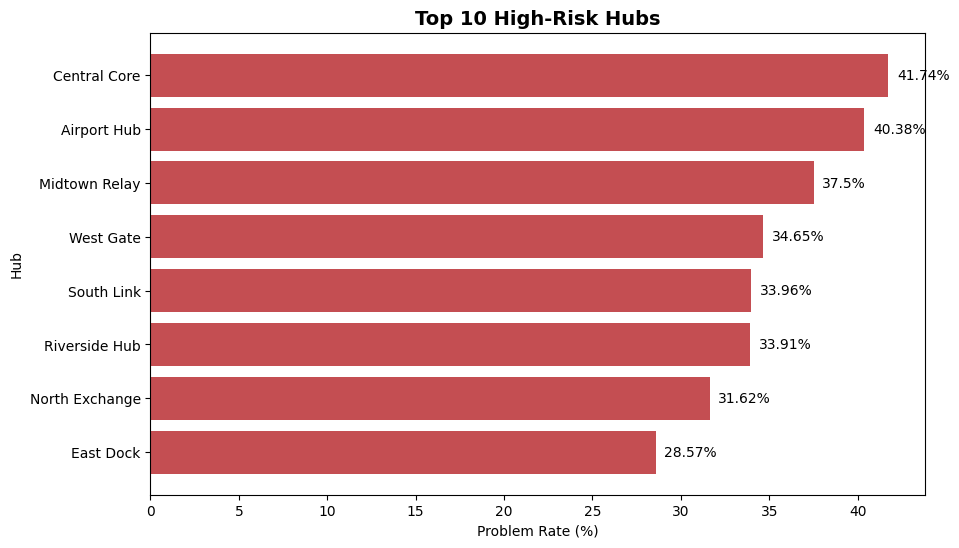

In [7]:
#-------------------(4)_HUB RISK VISUALISATION---------------------
#1 Select top 10 risky hubs
top_hubs = hub_kpi.head(10)

#2 Plot
plt.figure(figsize=(10,6))
plt.barh(top_hubs['hub_name'], top_hubs['problem_rate'], color="#C44E52")

plt.xlabel("Problem Rate (%)")
plt.ylabel("Hub")
plt.title("Top 10 High-Risk Hubs", fontsize=14, fontweight='bold')

plt.gca().invert_yaxis()

#3 Add labels
for i, v in enumerate(top_hubs['problem_rate']):
    plt.text(v + 0.5, i, f"{v}%", va='center')

plt.show()

In [8]:
#-------------------(5)_DRIVER RISK ANALYSIS---------------------
#1 Aggregate driver performance
driver_kpi = analysis_df.groupby('driver_id').agg(
    total_deliveries=('delivery_id', 'count'),
    problems=('is_problem', 'sum'),
    avg_rating=('customer_rating_post_delivery', 'mean'),
    training_score=('training_score', 'mean')
).reset_index()

#2 KPI calculation
driver_kpi['problem_rate'] = round(100 * driver_kpi['problems'] / driver_kpi['total_deliveries'], 2)

#3 Filter reliable drivers
driver_kpi = driver_kpi[driver_kpi['total_deliveries'] >= 5]

#4 Sort and display
driver_kpi = driver_kpi.sort_values(by='problem_rate', ascending=False)

display(driver_kpi.head(10))

,driver_id,total_deliveries,problems,avg_rating,training_score,problem_rate
99,D100,8,6,3.348750,62.0,75.00
52,D053,7,5,3.137143,83.3,71.43
22,D023,6,4,3.901667,79.1,66.67
140,D141,9,6,2.934444,71.4,66.67
164,D165,6,4,2.976667,82.2,66.67
91,D092,5,3,3.376000,88.2,60.00
4,D005,5,3,3.530000,69.7,60.00
155,D156,5,3,3.646000,84.5,60.00
161,D162,5,3,3.476000,69.0,60.00
94,D095,5,3,3.264000,99.0,60.00


In [9]:
#-------------------(6)_VEHICLE PERFORMANCE ANALYSIS---------------------
#1 Aggregate vehicle performance
vehicle_kpi = analysis_df.groupby('maintenance_status').agg(
    total_deliveries=('delivery_id', 'count'),
    problems=('is_problem', 'sum'),
    avg_battery=('battery_health_pct', 'mean')
).reset_index()

#2 KPI calculation
vehicle_kpi['problem_rate'] = round(100 * vehicle_kpi['problems'] / vehicle_kpi['total_deliveries'], 2)

#3 Sort and display
vehicle_kpi = vehicle_kpi.sort_values(by='problem_rate', ascending=False)

display(vehicle_kpi)

,maintenance_status,total_deliveries,problems,avg_battery,problem_rate
1,Inrepair,254,129,76.725984,50.79
2,Scheduled,154,47,78.735714,30.52
0,Active,542,158,76.630535,29.15


In [10]:
#-------------------(7)_COMPLAINT ANALYSIS---------------------
#1 Merge datasets
delivery_complaints = DELIVERY.merge(ORDER, on='order_id', how='left')
delivery_complaints = delivery_complaints.merge(COMPLAINT, on='order_id', how='left')

#2 Create complaint flag
delivery_complaints['has_complaint'] = delivery_complaints['complaint_id'].notna().astype(int)

#3 Aggregate
complaint_kpi = delivery_complaints.groupby('delivery_status').agg(
    total_deliveries=('delivery_id', 'count'),
    complaints=('has_complaint', 'sum')
).reset_index()

#4 KPI calculation
complaint_kpi['complaint_rate'] = round(100 * complaint_kpi['complaints'] / complaint_kpi['total_deliveries'], 2)

display(complaint_kpi)

,delivery_status,total_deliveries,complaints,complaint_rate
0,Delayed,205,48,23.41
1,Failed,134,35,26.12
2,Ontime,634,149,23.50


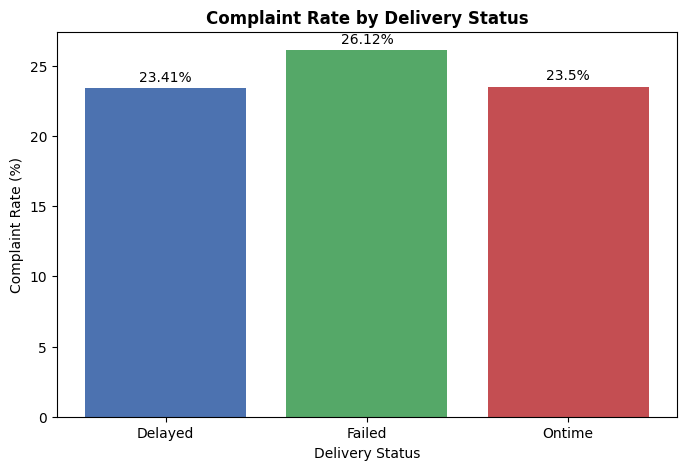

In [11]:
#-------------------(8)_COMPLAINT VISUALISATION---------------------
plt.figure(figsize=(8,5))

plt.bar(complaint_kpi['delivery_status'], complaint_kpi['complaint_rate'],
        color=['#4C72B0','#55A868','#C44E52','#8172B2'])

plt.xlabel("Delivery Status")
plt.ylabel("Complaint Rate (%)")
plt.title("Complaint Rate by Delivery Status", fontweight='bold')

# Add labels
for i, v in enumerate(complaint_kpi['complaint_rate']):
    plt.text(i, v + 0.5, f"{v}%", ha='center')

plt.show()

In [12]:
#-------------------(9)_APP EVENT ANALYSIS---------------------
#1 Aggregate app performance
app_kpi = APP_EVENT.groupby('event_type').agg(
    total=('event_id', 'count'),
    failures=('success_flag', lambda x: (x == 0).sum()),
    avg_latency=('api_latency_ms', 'mean')
).reset_index()

#2 KPI calculation
app_kpi['failure_rate'] = round(100 * app_kpi['failures'] / app_kpi['total'], 2)

#3 Sort and display
app_kpi = app_kpi.sort_values(by='failure_rate', ascending=False)

display(app_kpi)

,event_type,total,failures,avg_latency,failure_rate
1,chat_escalated,38,19,478.131579,50.00
5,payment_retry,69,19,472.681159,27.54
2,chat_opened,88,0,478.329545,0.00
0,cancel_attempt,28,0,417.142857,0.00
3,delivery_instruction_update,75,0,496.293333,0.00
4,eta_refresh,105,0,452.152381,0.00
6,search_route,99,0,456.505051,0.00
7,track_order,138,0,460.710145,0.00


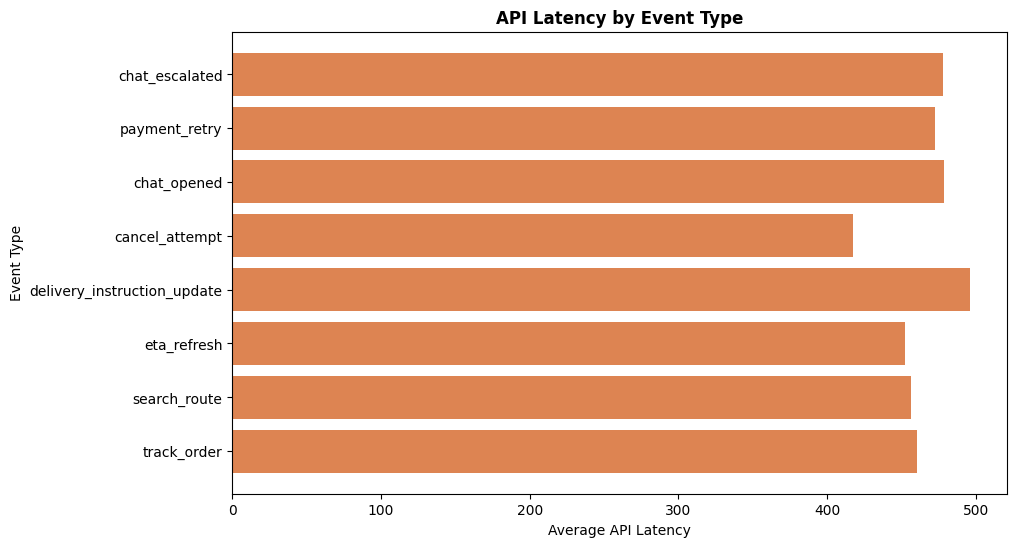

In [13]:
#-------------------(10)_APP LATENCY VISUALISATION---------------------
plt.figure(figsize=(10,6))

plt.barh(app_kpi['event_type'], app_kpi['avg_latency'], color="#DD8452")

plt.xlabel("Average API Latency")
plt.ylabel("Event Type")
plt.title("API Latency by Event Type", fontweight='bold')

plt.gca().invert_yaxis()

plt.show()

In [14]:
#-------------------(11)_CORRELATION ANALYSIS---------------------
#1 Select variables
corr_data = analysis_df[
    ['is_failed','is_delayed','is_problem',
     'customer_rating_post_delivery',
     'training_score','years_experience','battery_health_pct']
]

#2 Compute correlation
corr_matrix = corr_data.corr()

display(corr_matrix)

,is_failed,is_delayed,is_problem,customer_rating_post_delivery,training_score,years_experience,battery_health_pct
is_failed,1.000000,-0.208754,0.545541,-0.366797,0.059593,0.098744,-0.043883
is_delayed,-0.208754,1.000000,0.705736,-0.427049,-0.008174,0.028615,0.002219
is_problem,0.545541,0.705736,1.000000,-0.631686,0.036166,0.096055,-0.029889
customer_rating_post_delivery,-0.366797,-0.427049,-0.631686,1.000000,0.002149,-0.055027,-0.011077
training_score,0.059593,-0.008174,0.036166,0.002149,1.000000,0.160445,0.016033
years_experience,0.098744,0.028615,0.096055,-0.055027,0.160445,1.000000,-0.048105
battery_health_pct,-0.043883,0.002219,-0.029889,-0.011077,0.016033,-0.048105,1.000000


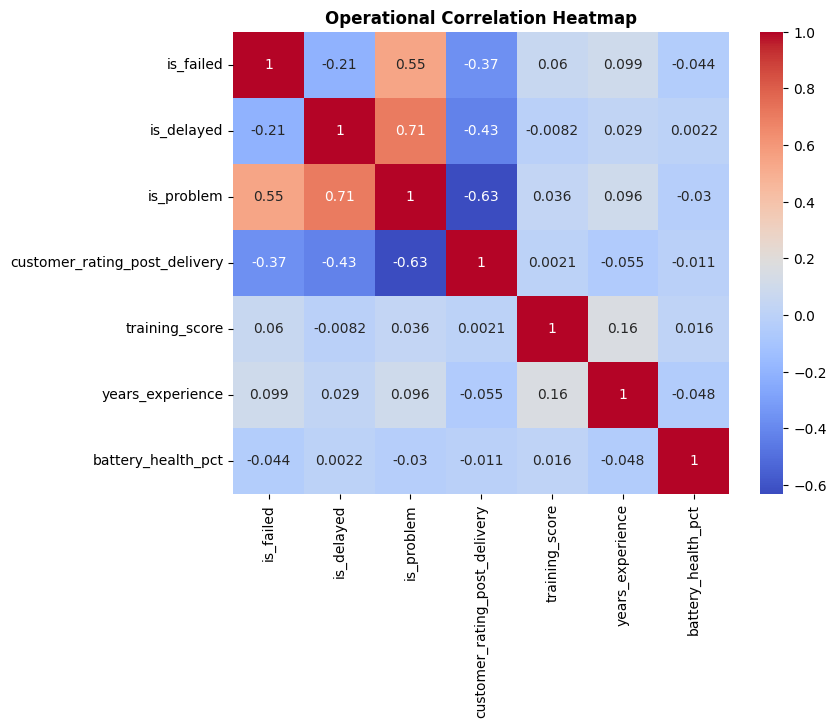

In [15]:
#-------------------(12)_CORRELATION HEATMAP---------------------
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Operational Correlation Heatmap", fontweight='bold')

plt.show()

In [16]:
#-------------------(13)_SAVE OUTPUTS---------------------
#1 Save all KPI outputs
hub_kpi.to_csv('Python_Hub_KPI.csv', index=False)
driver_kpi.to_csv('Python_Driver_KPI.csv', index=False)
vehicle_kpi.to_csv('Python_Vehicle_KPI.csv', index=False)
complaint_kpi.to_csv('Python_Complaint_KPI.csv', index=False)
app_kpi.to_csv('Python_App_KPI.csv', index=False)
corr_matrix.to_csv('Python_Correlation.csv')

print("All outputs saved successfully.")

All outputs saved successfully.
